<a href="https://colab.research.google.com/github/zaidbhat1234/Image2StyleGAN/blob/main/Image2Style_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Mounting your google drive containing the code files.


In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/My\ Drive/

##The code should be arranged in this order of directories

In [ ]:
%cd KAUST_Internship/StyleGAN_LatentEditor

##Resolving dependencies and importing libraries

In [1]:
from stylegan_layers import  G_mapping,G_synthesis
import torch
import torch.optim as optim
import torch.nn as nn
from collections import OrderedDict
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
import torchvision
from torchvision import models
from torchvision.utils import save_image
import numpy as np
from math import log10
import matplotlib.pyplot as plt


##Setup up the network on GPU

In [8]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
g_all = nn.Sequential(OrderedDict([
    ('g_mapping', G_mapping()),
    ('g_synthesis', G_synthesis(resolution=1024))    
]))

# Load the pre-trained model
g_all.load_state_dict(torch.load('karras2019stylegan-ffhq-1024x1024.for_g_all.pt', map_location=device))
g_all.eval()
g_all.to(device)
g_mapping, g_synthesis = g_all[0], g_all[1]

##Read Images for inverting to latent space W+ and using in various experiments

In [14]:
# Read the first video frame (Starting Image)
img_path = 'C:/Users/noelt/Desktop/UPF/CV_Seminar_Project/data/frames/video3/frame_0001.png'
with open(img_path,"rb") as f: 
    image = Image.open(f)
    image = image.convert("RGB")

# CRITICAL FIX: Resize your 480x864 frames to 1024x1024 for StyleGAN
transform = transforms.Compose([
    transforms.Resize((1024, 1024)), 
    transforms.ToTensor()
])

image = transform(image)
image = image.unsqueeze(0)
image = image.to(device)
print("Image 1 shape:", image.shape)

# Read a second video frame (e.g., 10 frames later for morphing)
img_path2 = 'C:/Users/noelt/Desktop/UPF/CV_Seminar_Project/data/frames/video3/frame_0010.png'
with open(img_path2,"rb") as f: 
    image1 = Image.open(f)
    image1 = image1.convert("RGB")

image1 = transform(image1)
image1 = image1.unsqueeze(0)
image1 = image1.to(device)
print("Image 2 shape:", image1.shape)

Image 1 shape: torch.Size([1, 3, 1024, 1024])
Image 2 shape: torch.Size([1, 3, 1024, 1024])


##Generate random images using random W vectors

In [16]:
for i in range(20):
  z = torch.randn(1,512,device = device)
  img = g_all(z)
  img = (img +1.0)/2.0
  save_image(img.clamp(0,1),"save_image/random_SG1-{}.png".format(i+1))

##VGG Perceptual loss network to give feature vectors from 4 parts of the pre-trained VGG-16 from 2,4,14,21

In [17]:
class VGG16_perceptual(torch.nn.Module):
    def __init__(self, requires_grad=False):
        super(VGG16_perceptual, self).__init__()
        vgg_pretrained_features = models.vgg16(pretrained=True).features
        self.slice1 = torch.nn.Sequential()
        self.slice2 = torch.nn.Sequential()
        self.slice3 = torch.nn.Sequential()
        self.slice4 = torch.nn.Sequential()
        for x in range(2):
            self.slice1.add_module(str(x), vgg_pretrained_features[x])
        for x in range(2, 4):
            self.slice2.add_module(str(x), vgg_pretrained_features[x])
        for x in range(4, 14):
            self.slice3.add_module(str(x), vgg_pretrained_features[x])
        for x in range(14, 21):
            self.slice4.add_module(str(x), vgg_pretrained_features[x])
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, X):
        h = self.slice1(X)
        h_relu1_1 = h
        h = self.slice2(h)
        h_relu1_2 = h
        h = self.slice3(h)
        h_relu3_2 = h
        h = self.slice4(h)
        h_relu4_2 = h
        return h_relu1_1, h_relu1_2, h_relu3_2, h_relu4_2

##Loss function to calculate MSE and Perceptual losses

In [18]:
def loss_function(syn_img, img, img_p, MSE_loss, upsample, perceptual):

  #UpSample synthesized image to match the input size of VGG-16 input. 
  #Extract mid level features for real and synthesized image and find the MSE loss between them for perceptual loss. 
  #Find MSE loss between the real and synthesized images of actual size
  syn_img_p = upsample(syn_img)
  syn0, syn1, syn2, syn3 = perceptual(syn_img_p)
  r0, r1, r2, r3 = perceptual(img_p)
  mse = MSE_loss(syn_img,img)

  per_loss = 0
  per_loss += MSE_loss(syn0,r0)
  per_loss += MSE_loss(syn1,r1)
  per_loss += MSE_loss(syn2,r2)
  per_loss += MSE_loss(syn3,r3)

  return mse, per_loss

##Calculate PSNR

In [19]:
def PSNR(mse, flag = 0):
  #flag = 0 if a single image is used and 1 if loss for a batch of images is to be calculated
  if flag == 0:
    psnr = 10 * log10(1 / mse.item())
  return psnr

In [21]:
psnr_total = []

##Embedding Function to optimise the latent code W+ for GAN inversion.

In [22]:
def embedding_function(image):
  upsample = torch.nn.Upsample(scale_factor = 256/1024, mode = 'bilinear')
  img_p = image.clone()
  img_p = upsample(img_p)
  #Perceptual loss initialise object
  perceptual = VGG16_perceptual().to(device)
  
  #MSE loss object
  MSE_loss = nn.MSELoss(reduction="mean")
  #since the synthesis network expects 18 w vectors of size 1x512 thus we take latent vector of the same size
  latents = torch.zeros((1,18,512), requires_grad = True, device = device)
  #Optimizer to change latent code in each backward step
  optimizer = optim.Adam({latents},lr=0.01,betas=(0.9,0.999),eps=1e-8)


  #Loop to optimise latent vector to match the generated image to input image
  loss_ = []
  loss_psnr = []
  for e in range(1500):
    optimizer.zero_grad()
    syn_img = g_synthesis(latents)
    syn_img = (syn_img+1.0)/2.0
    mse, per_loss = loss_function(syn_img, image, img_p, MSE_loss, upsample, perceptual)
    psnr = PSNR(mse, flag = 0)
    loss = per_loss +mse
    loss.backward()
    optimizer.step()
    loss_np=loss.detach().cpu().numpy()
    loss_p=per_loss.detach().cpu().numpy()
    loss_m=mse.detach().cpu().numpy()
    loss_psnr.append(psnr)
    loss_.append(loss_np)
    if (e+1)%500==0 :
      print("iter{}: loss -- {},  mse_loss --{},  percep_loss --{}, psnr --{}".format(e+1,loss_np,loss_m,loss_p,psnr))
      save_image(syn_img.clamp(0,1),"obama{}.png".format(e+1))
      #np.save("loss_list.npy",loss_)
      #np.save("latent_W.npy".format(),latents.detach().cpu().numpy())

  plt.plot(loss_, label = 'Loss = MSELoss + Perceptual')
  plt.plot(loss_psnr, label = 'PSNR')
  plt.legend()
  return latents

C:\Users\noelt\Desktop\UPF\CV_Seminar_Project\methods\editing\diffusers\cv_gpu_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\noelt\Desktop\UPF\CV_Seminar_Project\methods\editing\diffusers\cv_gpu_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to C:\Users\noelt/.cache\torch\hub\checkpoints\vgg16-397923af.pth


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 528M/528M [00:07<00:00, 75.1MB/s]


iter500: loss -- 3.6674091815948486,  mse_loss --0.03399868309497833,  percep_loss --3.6334104537963867, psnr --14.685379045948162
iter1000: loss -- 3.252098321914673,  mse_loss --0.03011532500386238,  percep_loss --3.221982955932617, psnr --15.212124455725176
iter1500: loss -- 3.0182740688323975,  mse_loss --0.027387237176299095,  percep_loss --2.990886926651001, psnr --15.624517771512092


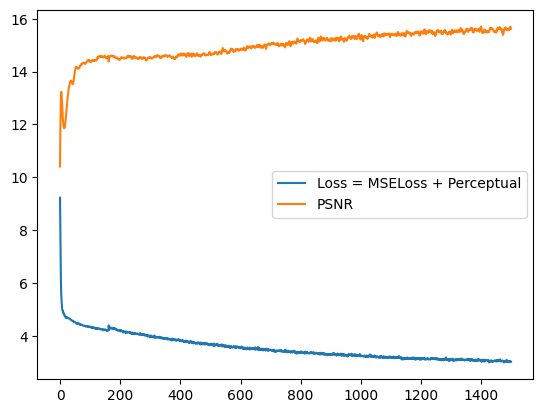

In [23]:
#Check generated images from 10 randomly generated faces 
"""Code in embed algo
rnd = np.random.RandomState(7)
z = torch.randn((1,512), requires_grad= True, device= device)
img1 = g_all(z)
img1 = (img1+1.0)/2.0
latents = g_mapping(z)
latents = torch.tensor(latents, requires_grad=True)
save_image(img1.clamp(0,1),"Random/random_image{}.png".format(i))"""

latent1 = embedding_function(image1)
#latent2 = embedding_function(image1)

##Image Morphing Experiment

In [26]:
for i in range(20):
  a = (1/20)*i
  w = latent1 * (1-a)+ latent1 * a
  syn_img = g_synthesis(w)
  syn_img = (syn_img+1.0)/2.0
  save_image(syn_img.clamp(0,1),"save_image/encode1/Morphed{}.png".format(i))

##Hierarchical Optimisation by optimising W vector first followed by optimising W+ in second pass

In [27]:
def embedding_Hierarchical(image):
  upsample = torch.nn.Upsample(scale_factor = 256/1024, mode = 'bilinear')
  img_p = image.clone()
  img_p = upsample(img_p)
  
  #Perceptual loss initialise object
  perceptual = VGG16_perceptual().to(device)
  
  #MSE loss object
  MSE_loss = nn.MSELoss(reduction="mean")
  #since the synthesis network expects 18 w vectors of size 1x512 thus we take latent vector of the same size
  latent_w = torch.zeros((1,512), requires_grad = True, device = device)
  
  #Optimizer to change latent code in each backward step
  optimizer = optim.Adam({latent_w},lr=0.01,betas=(0.9,0.999),eps=1e-8)


  #Loop to optimise latent vector to match the generated image to input image
  loss_ = []
  loss_psnr = []
  for e in range(1000):
    optimizer.zero_grad()
    latent_w1 = latent_w.unsqueeze(1).expand(-1, 18, -1)
    syn_img = g_synthesis(latent_w1)
    syn_img = (syn_img+1.0)/2.0
    mse, per_loss = loss_function(syn_img, image, img_p, MSE_loss, upsample, perceptual)
    psnr = PSNR(mse, flag = 0)
    loss = per_loss +mse
    loss.backward()
    optimizer.step()
    loss_np=loss.detach().cpu().numpy()
    loss_p=per_loss.detach().cpu().numpy()
    loss_m=mse.detach().cpu().numpy()
    loss_psnr.append(psnr)
    loss_.append(loss_np)
    if (e+1)%500==0 :
      print("iter{}: loss -- {},  mse_loss --{},  percep_loss --{}, psnr --{}".format(e+1,loss_np,loss_m,loss_p,psnr))
      save_image(syn_img.clamp(0,1),"Hier_pass_morphP1-{}.png".format(e+1))
      #np.save("loss_list.npy",loss_)
      #np.save("latent_W.npy".format(),latents.detach().cpu().numpy())

  
  latent_w1 = latent_w.unsqueeze(1).expand(-1, 18, -1)
  latent_w1 = torch.tensor(latent_w1, requires_grad=True)
  optimizer = optim.Adam({latent_w1},lr=0.01,betas=(0.9,0.999),eps=1e-8)
  for e in range(1000):  
    optimizer.zero_grad()
    syn_img = g_synthesis(latent_w1)
    syn_img = (syn_img+1.0)/2.0
    mse, per_loss = loss_function(syn_img, image, img_p, MSE_loss, upsample, perceptual)
    psnr = PSNR(mse, flag = 0)
    loss = per_loss +mse
    loss.backward()
    optimizer.step()
    loss_np=loss.detach().cpu().numpy()
    loss_p=per_loss.detach().cpu().numpy()
    loss_m=mse.detach().cpu().numpy()
    loss_psnr.append(psnr)
    loss_.append(loss_np)
    if (e+1)%500==0 :
      print("iter{}: loss -- {},  mse_loss --{},  percep_loss --{}, psnr --{}".format(e+1,loss_np,loss_m,loss_p,psnr))
      save_image(syn_img.clamp(0,1),"Hier_pass_morphP2-{}.png".format(e+1))


  plt.plot(loss_, label = 'Loss = MSELoss + Perceptual')
  plt.plot(loss_psnr, label = 'PSNR')
  plt.legend()
  return latent_w1

##Obtaining latent codes for 2 images using Hierarchical Optimisation to check Image Morphing

iter500: loss -- 4.53827428817749,  mse_loss --0.039685655385255814,  percep_loss --4.498588562011719, psnr --14.01366443181204
iter1000: loss -- 4.479629039764404,  mse_loss --0.037100162357091904,  percep_loss --4.44252872467041, psnr --14.306241898287592


C:\Users\noelt\AppData\Local\Temp\ipykernel_35812\2532359478.py:44: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  latent_w1 = torch.tensor(latent_w1, requires_grad=True)


iter500: loss -- 3.4153361320495605,  mse_loss --0.03305628523230553,  percep_loss --3.382279872894287, psnr --14.807459527535908
iter1000: loss -- 2.9977071285247803,  mse_loss --0.03208421543240547,  percep_loss --2.965622901916504, psnr --14.937085762120612
iter500: loss -- 4.3649001121521,  mse_loss --0.036439262330532074,  percep_loss --4.328460693359375, psnr --14.384304233846068
iter1000: loss -- 4.299957752227783,  mse_loss --0.03576704114675522,  percep_loss --4.264190673828125, psnr --14.465169856767874
iter500: loss -- 3.2019355297088623,  mse_loss --0.03055272065103054,  percep_loss --3.1713829040527344, psnr --15.149501107530018


KeyboardInterrupt: 

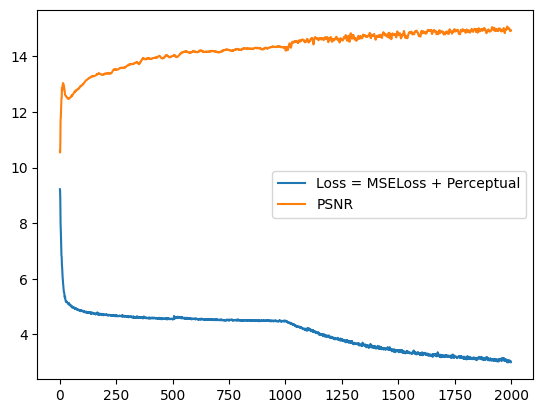

In [28]:
latent1 = embedding_Hierarchical(image)
latent2 = embedding_Hierarchical(image1)

In [ ]:
#Image Morphing Experiment
for i in range(20):
  a = (1/20)*i
  w = latent2 * (1-a)+ latent1 * a
  syn_img = g_synthesis(w)
  syn_img = (syn_img+1.0)/2.0
  save_image(syn_img.clamp(0,1),"Hier-Morphed{}.png".format(i))

In [1]:
print("1. Script started successfully! Importing libraries...")
from collections import OrderedDict
import glob
from math import log10
import os
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torchvision.utils import save_image
from stylegan_layers import G_mapping, G_synthesis

# ==========================================
# 1. CONFIGURATION
# ==========================================
FRAME_DIR = 'C:/Users/noelt/Desktop/UPF/CV_Seminar_Project/data/frames/video4/'
OUTPUT_DIR = 'C:/Users/noelt/Desktop/UPF/CV_Seminar_Project/data/frames/video4_inverted/'
MODEL_WEIGHTS_PATH = 'karras2019stylegan-ffhq-1024x1024.for_g_all.pt'

os.makedirs(OUTPUT_DIR, exist_ok=True)
STEPS_PER_FRAME = 500  
FRAME_SKIP = 10        

# ==========================================
# 2. MODEL INITIALIZATION
# ==========================================
print("2. Checking for GPU/CUDA acceleration...")
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print(f"   -> Using device: {device}")

print("3. Building StyleGAN network structure...")
g_all = nn.Sequential(OrderedDict([
    ('g_mapping', G_mapping()),
    ('g_synthesis', G_synthesis(resolution=1024))    
]))

print("4. Loading StyleGAN weights from disk (This can take 20-30 seconds)...")
g_all.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, map_location=device))
g_all.eval()

print("5. Moving StyleGAN to your GPU memory...")
g_all.to(device)
g_mapping, g_synthesis = g_all[0], g_all[1]

# VGG Perceptual Network Definition
class VGG16_perceptual(torch.nn.Module):
    def __init__(self, requires_grad=False):
        super(VGG16_perceptual, self).__init__()
        vgg_pretrained_features = models.vgg16(pretrained=True).features
        self.slice1 = torch.nn.Sequential()
        self.slice2 = torch.nn.Sequential()
        self.slice3 = torch.nn.Sequential()
        self.slice4 = torch.nn.Sequential()
        for x in range(2):
            self.slice1.add_module(str(x), vgg_pretrained_features[x])
        for x in range(2, 4):
            self.slice2.add_module(str(x), vgg_pretrained_features[x])
        for x in range(4, 14):
            self.slice3.add_module(str(x), vgg_pretrained_features[x])
        for x in range(14, 21):
            self.slice4.add_module(str(x), vgg_pretrained_features[x])
        if not requires_grad:
            for param in self.parameters():
                param.requires_grad = False

    def forward(self, X):
        h = self.slice1(X)
        h_relu1_1 = h
        h = self.slice2(h)
        h_relu1_2 = h
        h = self.slice3(h)
        h_relu3_2 = h
        h = self.slice4(h)
        h_relu4_2 = h
        return h_relu1_1, h_relu1_2, h_relu3_2, h_relu4_2

print("6. Loading VGG16 Perceptual Network...")
perceptual = VGG16_perceptual().to(device)
MSE_loss = nn.MSELoss(reduction="mean")
upsample = torch.nn.Upsample(scale_factor=256/1024, mode='bilinear')

def loss_function(syn_img, img, img_p):
    syn_img_p = upsample(syn_img)
    syn0, syn1, syn2, syn3 = perceptual(syn_img_p)
    r0, r1, r2, r3 = perceptual(img_p)
    mse = MSE_loss(syn_img, img)
    per_loss = 0
    per_loss += MSE_loss(syn0, r0)
    per_loss += MSE_loss(syn1, r1)
    per_loss += MSE_loss(syn2, r2)
    per_loss += MSE_loss(syn3, r3)
    return mse, per_loss

def PSNR(mse):
    return 10 * log10(1 / mse.item())

# ==========================================
# 4. PROCESSING LOOP
# ==========================================
print(f"7. Scanning your directory for frames at: {FRAME_DIR}")
all_frame_paths = sorted(glob.glob(os.path.join(FRAME_DIR, '*.png')))
selected_frames = all_frame_paths[::FRAME_SKIP]

print(f"   -> Total video frames found on disk: {len(all_frame_paths)}")
print(f"   -> Frames selected to process: {len(selected_frames)}")

if len(selected_frames) == 0:
    print("❌ ERROR: No frames found! Double check your FRAME_DIR path syntax.")

transform = transforms.Compose([
    transforms.Resize((1024, 1024)), 
    transforms.ToTensor()
])

print("\n8. Starting Optimization loop...")
for idx, img_path in enumerate(selected_frames):
    frame_basename = os.path.basename(img_path)
    print(f"\n--- Processing [{idx + 1}/{len(selected_frames)}]: {frame_basename} ---")
    
    with open(img_path, "rb") as f: 
        image = Image.open(f).convert("RGB")
    
    image = transform(image).unsqueeze(0).to(device)
    img_p = upsample(image.clone())
    
    latents = torch.zeros((1, 18, 512), requires_grad=True, device=device)
    optimizer = optim.Adam({latents}, lr=0.01, betas=(0.9, 0.999), eps=1e-8)
    
    for e in range(STEPS_PER_FRAME):
        optimizer.zero_grad()
        syn_img = g_synthesis(latents)
        syn_img = (syn_img + 1.0) / 2.0
        
        mse, per_loss = loss_function(syn_img, image, img_p)
        loss = per_loss + mse
        loss.backward()
        optimizer.step()
        
        if (e + 1) % 100 == 0:  # Changed to print every 100 steps so you see faster updates
            psnr_val = PSNR(mse)
            print(f"  Step {e + 1}/{STEPS_PER_FRAME} | Loss: {loss.item():.4f} | PSNR: {psnr_val:.2f}")
            
    final_out_path = os.path.join(OUTPUT_DIR, f"inverted_{frame_basename}")
    save_image(syn_img.clamp(0, 1), final_out_path)
    print(f"💾 Saved optimized frame reconstruction to: {final_out_path}")

print("\nAll tasks complete!")

1. Script started successfully! Importing libraries...
2. Checking for GPU/CUDA acceleration...
   -> Using device: cuda:0
3. Building StyleGAN network structure...
4. Loading StyleGAN weights from disk (This can take 20-30 seconds)...
5. Moving StyleGAN to your GPU memory...
6. Loading VGG16 Perceptual Network...


C:\Users\noelt\Desktop\UPF\CV_Seminar_Project\methods\editing\diffusers\cv_gpu_env\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\noelt\Desktop\UPF\CV_Seminar_Project\methods\editing\diffusers\cv_gpu_env\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


7. Scanning your directory for frames at: C:/Users/noelt/Desktop/UPF/CV_Seminar_Project/data/frames/video4/
   -> Total video frames found on disk: 152
   -> Frames selected to process: 16

8. Starting Optimization loop...

--- Processing [1/16]: frame_0001.png ---
  Step 100/500 | Loss: 2.0382 | PSNR: 14.30
  Step 200/500 | Loss: 1.4787 | PSNR: 17.99
  Step 300/500 | Loss: 1.2014 | PSNR: 20.12
  Step 400/500 | Loss: 0.9847 | PSNR: 20.36
  Step 500/500 | Loss: 0.9013 | PSNR: 20.97
💾 Saved optimized frame reconstruction to: C:/Users/noelt/Desktop/UPF/CV_Seminar_Project/data/frames/video4_inverted/inverted_frame_0001.png

--- Processing [2/16]: frame_0011.png ---
  Step 100/500 | Loss: 2.5800 | PSNR: 13.72
  Step 200/500 | Loss: 1.9454 | PSNR: 16.82
  Step 300/500 | Loss: 1.4918 | PSNR: 19.01
  Step 400/500 | Loss: 1.3172 | PSNR: 19.64
  Step 500/500 | Loss: 1.2211 | PSNR: 19.83
💾 Saved optimized frame reconstruction to: C:/Users/noelt/Desktop/UPF/CV_Seminar_Project/data/frames/video4_in

Downsamplimg to use a deeper network as it reduces computational cost as well as to increase receptive field. As downsampled image each pixel in it will have a wider receptive area it will affect in the actual higher dimensional image.

Instead of pixel wise similarity we push for similarity in feature representations of real and synthesized images.

Downsample to match the input size expectation of VGG - 256 or 224

Taken Perceptual loss online official implementation

We dont need the mapping part of the StyleGAN but only synthesis part which expects input as 1 x 18 x 512 i.e, 18 w's each input into the layers of Synthesis part.